In [1]:
%run general_functions.ipynb

In [2]:
dic = xr.open_dataset('/Users/chiaraciscato/Desktop/GEOMAR/2024_ciscato_oae_seasonality/lastDecade/DIC_base26_lastDecade.nc')
mld = xr.open_dataset('/Users/chiaraciscato/Desktop/GEOMAR/2024_ciscato_oae_seasonality/lastDecade/mld_base26_lastDecade.nc')
npp = xr.open_dataset('/Users/chiaraciscato/Downloads/wetransfer_npp_2025-06-18_0759/npp_base_26.nc')
sst = xr.open_dataset('/Users/chiaraciscato/Downloads/sst.nc')

In [3]:
mesh_mask = xr.open_dataset('/Users/chiaraciscato/Desktop/GEOMAR/2024_ciscato_oae_seasonality/lastDecade/mesh_mask.nc')

In [4]:
mesh_mask = mesh_mask.tmask.isel(t=0,z=0).sel(x=slice(520, 595), y=slice(330, 435))
mesh_mask = mesh_mask.where(mesh_mask)

In [5]:
# variable units
units = var_units()
# labels
lat_labels, lon_labels = lat_lon_labels()

In [6]:
def geo_weight(data, var):
    
    weights = np.cos(np.deg2rad(data.nav_lat))
    weights.name = "weights"

    data_weighted = data.weighted(weights)
    weighted_mean = data_weighted.mean(dim=("x"))
    
    return weighted_mean

In [7]:
def ns_polygon(data):
    polygon_coords = [(42,70),(55, 80), (69, 53), (58, 34),(41, 61)]
    
    x = data['x'].values
    y = data['y'].values
    
    X, Y = np.meshgrid(x, y)
    points = np.vstack((X.ravel(), Y.ravel())).T
    
    poly_path = Path(polygon_coords)
    ns_mask = poly_path.contains_points(points).reshape(X.shape)

    return ns_mask

In [8]:
def depth_mask(data, var, depth):
    d = copy.deepcopy(data)
    attrs = d[var].attrs.copy()

    mask = ns_polygon(d)
    d = (d * mask).isel(time_counter=0)

    d = d.where(d)

    d[var] = d[var].notnull().astype(int)
    
    mask_sum = d[var].sum(dim=depth).astype(int)

    depth_levels = xr.DataArray(data[depth].values, dims=[depth], coords={depth: data[depth]})
    mask_depth_values = mask_sum.copy()

    for i, depth_value in enumerate(depth_levels):
        mask_depth_values = mask_depth_values.where(mask_sum != i + 1, depth_value)

    mask_ds = mask_depth_values.to_dataset(name='depth')
    mask_ds = mask_ds.where(mask_ds['depth'].notnull())

    mask_ds = (mask_ds * mask)
    mask_ds = mask_ds.where(mask_ds)

    return mask_ds

In [9]:
bathymetry = depth_mask(dic, 'DIC', 'deptht')

In [10]:
def slicing(data, mld, var):
    mld_bool = (data['deptht'] < mld.somxl010).to_dataset(name='mld') 
    data *= mld_bool['mld']
    data = data.where(data).fillna(0)
    layers_sum = [
        data[var].isel(deptht=x) * (data.deptht[x] if x == 0 else (data.deptht[x] - data.deptht[x - 1]))
        for x in range(len(data.deptht))
    ]
    
    weighted_var = (sum(layers_sum) / mld.somxl010).to_dataset(name=var)
    return weighted_var

In [11]:
def monthly_means(data, var):

    attrs = data[var].attrs
    data = data.where(data)
    
    if 'deptht' in data.dims:
        data = data.isel(deptht=0)
        
    mask = ns_polygon(data)
    
    # if var == 'DIC':
    #     data = slicing(data, mld, var)

    data = data.sel(time_counter=slice('2090','2099'))
    
    m_lenght = data[var].time_counter.dt.days_in_month
    data = (data[var] * m_lenght).groupby("time_counter.month").mean(dim="time_counter") / m_lenght.groupby("time_counter.month").mean(dim="time_counter")
    data = data.to_dataset(name=var)

    data = data * mask
    data = geo_weight(data, var)
    
    data[var].attrs = attrs
    data = data.where(data, drop=True)

    return data

In [12]:
def homvoller(data, var, ax, vmin, vmax):
    im = ax.pcolormesh(data[var].T,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )
    c = plt.colorbar(im, ax=ax, aspect=12, pad=0.02, location='top', extend='max')                       
    c.ax.set_frame_on(False)
    c.ax.tick_params(labelsize=12)

    c.set_label(
            f"{list(units[var].keys())[0]} [{list(units[var].values())[0]}]",
            labelpad=14
        )
    
    return im

In [13]:
cmap, norm = create_discrete_cmap(cm.rainforest_r,40)

In [14]:
dic = monthly_means(dic, 'DIC')
mld_f = monthly_means(mld, 'somxl010')
npp_f = monthly_means(npp, 'bgc_diag_pp')
sst_f = monthly_means(sst, 'sosstsst')

In [15]:
d = '$^\circ$'

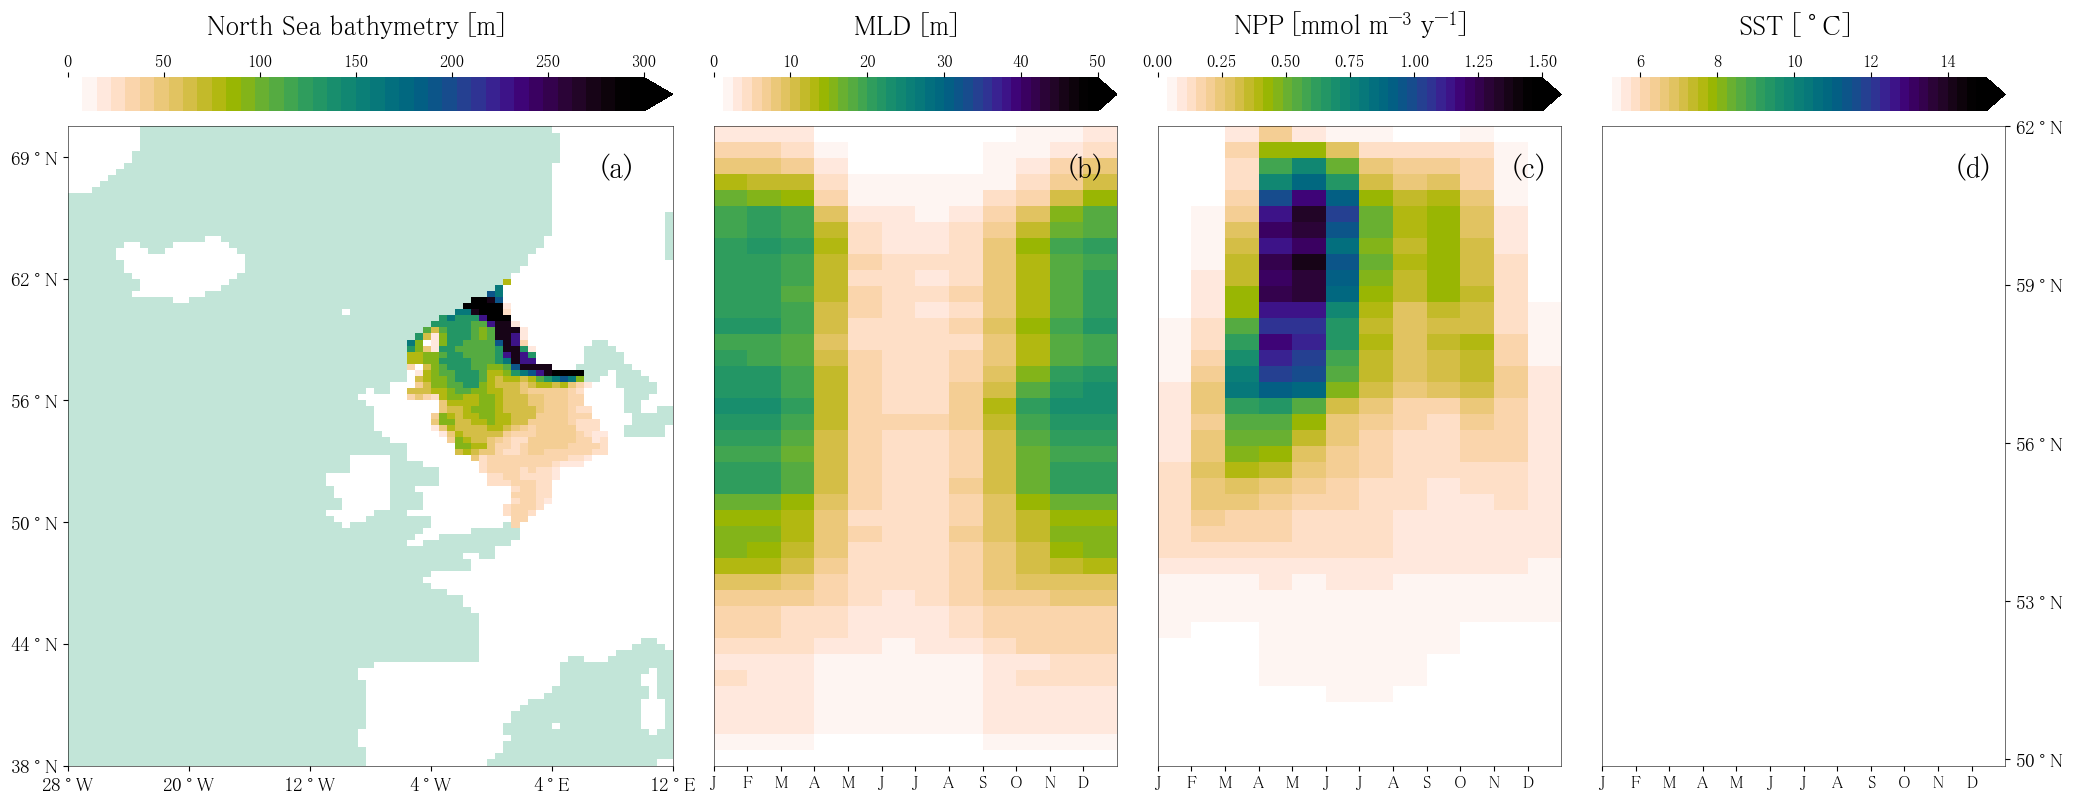

In [16]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(
    ncols=4,
    figsize=(25, 10),
    gridspec_kw={'width_ratios': [1.5, 1, 1, 1]}
)
plt.subplots_adjust(wspace=0.09)

im = ax1.pcolormesh(
        mesh_mask,
        cmap=sns.cubehelix_palette(start=.5, rot=-.5, as_cmap=True),
    )

im = ax1.pcolormesh(
        bathymetry['depth'],
        cmap=cmap,
        vmin=0,
        vmax=300
    )

ax1.set_xticks([0,15,30,45,60,75])
ax1.set_yticklabels(lat_labels, fontsize=14)
ax1.set_xticklabels(lon_labels, fontsize=14)
                         # year
im_npp = homvoller(npp_f*31536000, 'bgc_diag_pp', ax3, 0, 1.5)
im_mld = homvoller(mld_f, 'somxl010', ax2, 0, 50)
im_sst = homvoller(sst_f, 'sosstsst', ax4, 5, 15)

# im_dic = homvoller(dic, 'DIC', ax4, 1500, 2000)

cbar = plt.colorbar(im, ax=ax1, aspect=18, pad=0.02, location='top', extend='max')
cbar.ax.set_frame_on(False)
cbar.ax.tick_params(labelsize=12)
cbar.set_label('North Sea bathymetry [m]', labelpad=14)

for ax in [ax2, ax3,ax4]:
    month_x_labels(ax)
    ax.set_ylim(0,40)
    if ax in [ax2,ax3]:
        ax.axes.get_yaxis().set_visible(False)

for n, ax in enumerate([ax1,ax2,ax3,ax4]):
    for location in ['left','bottom', 'right', 'top']:
        ax.spines[location].set_linewidth(0.4)
    ax.text(0.88, 0.92, string.punctuation[7] + string.ascii_lowercase[n] + string.punctuation[8],
        transform=ax.transAxes, size=22, weight='bold', color='black')

y = list(range(1,130))
ax4.set_yticks(np.arange(min(y), max(y), 26))
labels_lat = [item.get_text() for item in ax1.get_yticklabels()]
lat_label = [f'50{d}N',f'53{d}N',f'56{d}N',f'59{d}N',f'62{d}N']
ax4.set_yticklabels(lat_label, fontsize=14)
ax4.yaxis.tick_right()

pass

plt.savefig('/Users/chiaraciscato/Desktop/GEOMAR/2024_ciscato_oae_seasonality/out/northSea_updated.png')